Homework 6
====================
ASEN 5264 Decision Making Under Uncertainty  
Cavlin Henggeler


In [98]:
using POMDPs
using DMUStudent.HW6
using POMDPTools: transition_matrices, reward_vectors, SparseCat, Deterministic, RolloutSimulator, DiscreteBelief, FunctionPolicy, ordered_states, ordered_actions, DiscreteUpdater, transition, UnderlyingMDP
using QuickPOMDPs: QuickPOMDP
using POMDPModels: TigerPOMDP, TIGER_LEFT, TIGER_RIGHT, TIGER_LISTEN, TIGER_OPEN_LEFT, TIGER_OPEN_RIGHT
using NativeSARSOP: SARSOPSolver
using POMDPTesting: has_consistent_distributions
using QMDP: QMDPSolver
using Plots
using Statistics: std
using POMDPPolicies: alphavectors, FunctionPolicy


### Problem 1

In [79]:
# ----------------------------------
# Updater: Rejection Particle Filter
# ----------------------------------

struct HW6Updater{M<:POMDP} <: Updater
    m::M
end

# This is needed to automatically turn any distribution into a discrete belief.
function POMDPs.initialize_belief(up::HW6Updater, distribution::Any)
    b_vec = zeros(length(states(up.m)))

    for s in states(up.m)
        b_vec[stateindex(up.m, s)] = pdf(distribution, s)
    end
    return DiscreteBelief(up.m, b_vec)
end

function POMDPs.update(up::HW6Updater, b::DiscreteBelief, a, o)

    # bp = statetype(m)[]     # initialize new belief structure similar to the old?
    # Note that the ordering of the entries in bp_vec must be consistent with stateindex(m, s) 
    #(the container returned by states(m) does not necessarily obey this order)
    #states = ordered_states(up.m)

    # states = similar(b.states)
    #states = ordered_states(up.m)              
    bp_vec = zeros(length(states(up.m)))        # initialize vector of next beleif b'. represents states
    num_particles = length(b.b)
    
    # simulate particles
    accepted_obs = 0
    while accepted_obs < num_particles
        s = rand(b)
        sp, o_gen = @gen(:sp, :o)(up.m, s, a)    # Genertive model for s' and o
        if o_gen == o
            # update belief
            idx = stateindex(up.m, sp) # get index of the new state
            bp_vec[idx] += 1 
            accepted_obs += 1
        end
    end 

    # normalize the belief vector
    bp_vec = bp_vec ./ sum(bp_vec) # normalize the belief vector to sum to 1

    # return a descrete belief b' represeting s'
    return DiscreteBelief(up.m, bp_vec) # im not sure im using this correctly
end

#-------
# Policy
#-------

struct HW6AlphaVectorPolicy{A} <: Policy
    alphas::Vector{Vector{Float64}} # alpha vectors
    alpha_actions::Vector{A}        # actions associated with alpha vectors
end

function POMDPs.action(p::HW6AlphaVectorPolicy, b::DiscreteBelief)
    
    beliefvec(b::DiscreteBelief) = b.b

    i = argmax([a.*b.b for a in p.alphas])

    return p.alpha_actions[i] # return the action associated with the best alpha vector

end

#------
# QMDP
#------

function qmdp_solve(m, discount=discount(m))
    S = ordered_states(m)            # States of the POMDP
    A = actions(m)                   # Actions of the POMDP
    n_states = length(S)

    # Initialize one alpha vector per action (each a vector of Float64s)
    alphas_Γ = [zeros(n_states) for _ in A]  # Vector{Vector{Float64}}
    acts = actiontype(m)[]  # Will store the action for each alpha vector

    # Alpha vector update function for a single action
    function alphas_update!(m, alphas_Γ, a_vec, a, discount, S)
        for (i, s) in enumerate(S)
            total = 0.0
            for (j, sp) in enumerate(S)
                T_sp_s_a = pdf(transition(m, s, a), sp)
                max_alpha_sp = maximum(alpha_p[j] for alpha_p in alphas_Γ)
                total += T_sp_s_a * max_alpha_sp
            end
            a_vec[i] = reward(m, s, a) + discount * total
        end
    end

    # Perform value iteration for a single action
    function alpha_vector_iteration!(m, alphas_Γ, discount, S, a; k_iters=10)
        a_vec = zeros(n_states)
        for k in 1:k_iters
            alphas_update!(m, alphas_Γ, a_vec, a, discount, S)
        end
        return a_vec
    end

    # Main QMDP loop
    for (i, a) in enumerate(A)
        αa = alpha_vector_iteration!(m, alphas_Γ, discount, S, a, k_iters=10)
        alphas_Γ[i] = αa          # store the computed alpha vector
        push!(acts, a)            # record associated action
    end

    return HW6AlphaVectorPolicy(alphas_Γ, acts)
end



qmdp_solve (generic function with 2 methods)

In [80]:
m = TigerPOMDP()
up = HW6Updater(m)
# up = DiscreteUpdater(m)

HW6Updater{TigerPOMDP}(TigerPOMDP(-1.0, -100.0, 10.0, 0.85, 0.95))

In [81]:
# QMDP.jl package
qmdp_verify = solve(QMDPSolver(),m)
optimal_qmdp_scores = [simulate(RolloutSimulator(max_steps=500), m, qmdp_verify, up) for _ in 1:5000]
@show std(optimal_qmdp_scores) / sqrt(length(optimal_qmdp_scores))

1.8632335612864073

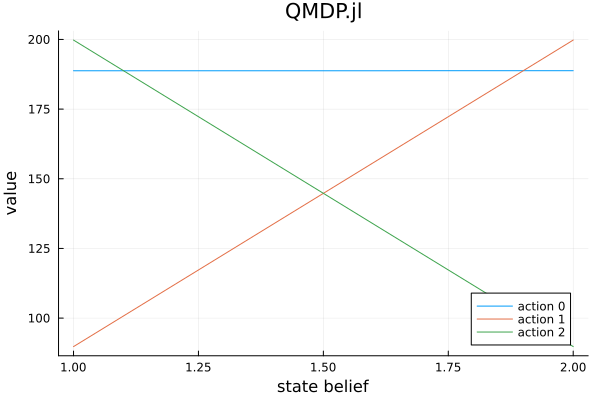

In [82]:
p1 = plot(xlabel="state belief", ylabel="value", title="QMDP.jl")
for (i, alpha_vec) in enumerate(qmdp_verify.alphas)
    plot!(p1, qmdp_verify.alphas[i], label="action $(qmdp_verify.action_map[i])")
end
p1

In [83]:
# My QMDP
qmdp_p = qmdp_solve(m)
my_qmdp_scores = [simulate(RolloutSimulator(max_steps=500), m, qmdp_p, up) for _ in 1:5000]
@show std(my_qmdp_scores) / sqrt(length(my_qmdp_scores))

2.4882134544757335

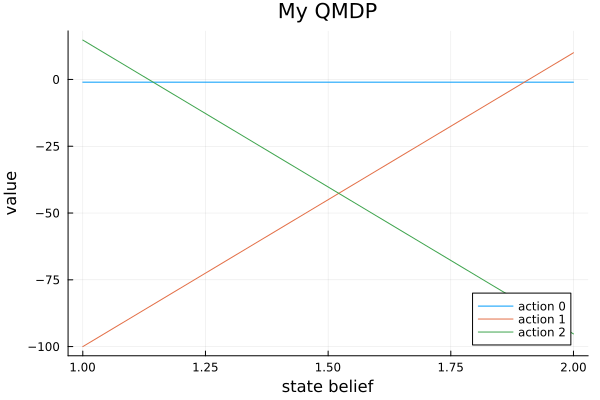

In [84]:
p2 = plot(xlabel="state belief", ylabel="value", title="My QMDP")
for (i, alpha_vec) in enumerate(qmdp_p.alphas)
    plot!(p2, qmdp_p.alphas[i], label="action $(qmdp_p.alpha_actions[i])")
end
p2

In [85]:
# SARSOP
sarsop_p = solve(SARSOPSolver(), m)
sarsop_scores = [simulate(RolloutSimulator(max_steps=500), m, sarsop_p, up) for _ in 1:5000]
@show std(sarsop_scores) / sqrt(length(sarsop_scores))

1.8767788740239961

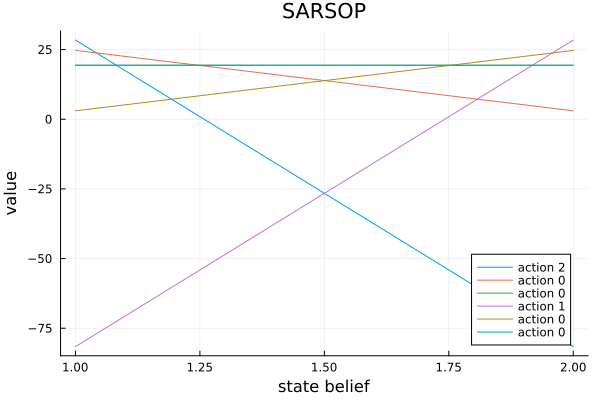

In [86]:

p3 = plot(xlabel="state belief", ylabel="value", title="SARSOP")
for (i, alpha_vec) in enumerate(sarsop_p.alphas)
    plot!(p3, alphavectors(sarsop_p)[i], label="action $(sarsop_p.action_map[i])")
end
p3

### Question 2
Evaluate the cancer problem using QMDP, a heuristic policy, and SARSOP.jl

In [87]:
cancer = QuickPOMDP(
    states = [:healthy, :in_situ, :invasive, :death],
    actions = [:wait, :test, :treat],
    observations = [true, false],

    transition = function (s, a)
        if s == :healthy
            return SparseCat([:healthy, :in_situ], [0.98, 0.02])
        elseif s == :in_situ
            if a == :treat
                return SparseCat([:healthy, :in_situ], [0.6, 0.4])
            else
                return SparseCat([:in_situ, :invasive], [0.9, 0.1])
            end
        elseif s == :invasive
            if a == :treat
                return SparseCat([:healthy, :death, :invasive], [0.2, 0.2, 0.6])
            else
                return SparseCat([:invasive, :death], [0.4, 0.6])
            end
        else
            return Deterministic(:death)
        end
    end,

    observation = function (a, sp)
        if a == :test
            if sp == :healthy
                return SparseCat([true, false], [0.05, 0.95])
            elseif sp == :in_situ
                return SparseCat([true, false], [0.8, 0.2])
            else
                return Deterministic(true)
            end
        elseif a == :treat
            if sp in (:in_situ, :invasive)
                return Deterministic(true)
            end
        end
        return Deterministic(false)
    end,

    reward = function (s, a)
        if s == :death
            return 0.0
        elseif a == :wait
            return 1.0
        elseif a == :test
            return 0.8
        elseif a == :treat
            return 0.1
        end
    end,

    discount = 0.99,
    initialstate = Deterministic(:healthy),
    isterminal = s->s==:death,
)

@assert has_consistent_distributions(cancer)

In [88]:
# qmdp_cancer = qmdp_solve(cancer)
sarsop_cancer = solve(SARSOPSolver(), cancer)
qmdp_cancer = solve(QMDPSolver(),cancer)

# up = HW6Updater(cancer)
up_cancer = DiscreteUpdater(cancer)

DiscreteUpdater{QuickPOMDP{Base.UUID("ec6fb4de-7a4a-4665-b0de-3d16aae3c00b"), Symbol, Symbol, Bool, @NamedTuple{stateindex::Dict{Symbol, Int64}, isterminal::var"#146#150", obsindex::Dict{Bool, Int64}, states::Vector{Symbol}, observations::Vector{Bool}, discount::Float64, actions::Vector{Symbol}, observation::var"#144#148", actionindex::Dict{Symbol, Int64}, transition::var"#143#147", reward::var"#145#149", initialstate::Deterministic{Symbol}}}}(QuickPOMDP{Base.UUID("ec6fb4de-7a4a-4665-b0de-3d16aae3c00b"), Symbol, Symbol, Bool, @NamedTuple{stateindex::Dict{Symbol, Int64}, isterminal::var"#146#150", obsindex::Dict{Bool, Int64}, states::Vector{Symbol}, observations::Vector{Bool}, discount::Float64, actions::Vector{Symbol}, observation::var"#144#148", actionindex::Dict{Symbol, Int64}, transition::var"#143#147", reward::var"#145#149", initialstate::Deterministic{Symbol}}}((stateindex = Dict(:death => 4, :in_situ => 2, :invasive => 3, :healthy => 1), isterminal = var"#146#150"(), obsindex = D

In [89]:
heuristic = FunctionPolicy(function (b)

        # Access state probabilities from the belief
        p_invasive = pdf(b, :invasive)
        p_insitu   = pdf(b, :in_situ)

        # If we are not yet confident (uncertain), gather information
        if p_invasive + p_insitu > 0.35
            return :treat
        else
            # Let QMDP take over for action selection
            return action(qmdp_cancer, b)
        end
    end)    # function(b)



FunctionPolicy{var"#151#152"}(var"#151#152"())

In [90]:
@show mean(simulate(RolloutSimulator(), cancer, sarsop_cancer, up_cancer) for _ in 1:1000)   # Should be approximately 79

78.32207746610888

In [91]:
@show mean(simulate(RolloutSimulator(), cancer, qmdp_cancer, up_cancer) for _ in 1:1000)     # Should be approximately 66

58.048665548042145

In [92]:
@show mean(simulate(RolloutSimulator(), cancer, heuristic, up_cancer) for _ in 1:1000)

58.512304390640814

Results Table: 
Model | QMDP  | Heuristic | SARSOP
------|-------|-----------|-------
Tiger | 1.88  |   N/A     | 1.91
Cancer| 58.21 |  60.55    | 77.59

The performance gap between QMDP and SARSOP is much larger on the Cancer problem. This might be because the observations of the cancer problem are noisier and QMDP assumes full observability after a step and takes actions accordingly and does not value information gathering actions as much, which becomes more important when states are likely to transition such as in the cancer problem.


### Problem 3

In [106]:
using ParticleFilters
using BasicPOMCP
using DiscreteValueIteration

lasertag_m = LaserTagPOMDP()
up_laser = DiscreteUpdater(lasertag_m)
underlying_m = UnderlyingMDP(lasertag_m)
rollout_policy = solve(ValueIterationSolver(max_iterations=200, belres=1e-6, verbose=true), underlying_m)
# filter = BasicParticleFilter(lasertag_m, 10000)

ValueIterationPolicy:
 LTState([1, 1], [1, 1], [1, 1]) -> :left
 LTState([2, 1], [1, 1], [1, 1]) -> :left
 LTState([3, 1], [1, 1], [1, 1]) -> :left
 LTState([4, 1], [1, 1], [1, 1]) -> :left
 LTState([5, 1], [1, 1], [1, 1]) -> :left
 LTState([6, 1], [1, 1], [1, 1]) -> :left
 LTState([7, 1], [1, 1], [1, 1]) -> :left
 LTState([8, 1], [1, 1], [1, 1]) -> :left
 LTState([9, 1], [1, 1], [1, 1]) -> :up
 LTState([10, 1], [1, 1], [1, 1]) -> :left
 LTState([1, 2], [1, 1], [1, 1]) -> :down
 LTState([2, 2], [1, 1], [1, 1]) -> :left
 LTState([3, 2], [1, 1], [1, 1]) -> :left
 LTState([4, 2], [1, 1], [1, 1]) -> :down
 LTState([5, 2], [1, 1], [1, 1]) -> :left
 LTState([6, 2], [1, 1], [1, 1]) -> :left
 LTState([7, 2], [1, 1], [1, 1]) -> :left
 LTState([8, 2], [1, 1], [1, 1]) -> :left
 LTState([9, 2], [1, 1], [1, 1]) -> :left
 …

In [107]:
qmdp_ltag = solve(QMDPSolver(), lasertag_m)
@show HW6.evaluate((qmdp_ltag,up_laser),n_episodes=100)

(score = 11.363086109578946,)

In [108]:
# POMCP.jl Solver
# ---------------

#A good approach to try is POMCP, implemented in the BasicPOMCP.jl package:
using BasicPOMCP
function pomcp_solve(m) # this function makes capturing m in the rollout policy more efficient
    solver = POMCPSolver(tree_queries=50,
                         c=20,
                         default_action=last(actions(lasertag_m)),
                         estimate_value=FORollout(FunctionPolicy(s-> action(rollout_policy, s))),
                         )
    return solve(solver, lasertag_m)
end
pomcp_p = pomcp_solve(lasertag_m)

@show HW6.evaluate((pomcp_p, up_laser), n_episodes=100)


(score = 23.64547280737951,)

In [109]:
# When you get ready to submit, use this version with the full 1000 episodes
HW6.evaluate((pomcp_p, up_laser), "calvin.henggeler@colorado.edu")

(assignment = "hw6", email = "calvin.henggeler@colorado.edu", score = 24.52693674633657, hash = "bbf3f2a3ad831e4d64ed0075f1556f2ff145d5dd23d3cec7093feac02a40475d")

My strategy to solve this problem was to use the POMCP online solver to accommodate the state space. The random action selection of the rollout policy was not idea so I used a value iteration solution of the underlying MDP. I used was the DisctreteUpdater.